### ***01: Import Libraries and Load Data***

In [2]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

#--Loading the trained model and scaler from files
model = joblib.load("..\\03_models\\car_buyer_model.pkl")          #--Loading the trained classification model for car buyer prediction
scaler = joblib.load("..\\03_models\\scaler.pkl")                  #--Loading the trained scaler for feature normalization

india_df = pd.read_csv("..\\01_data\\02_processed\\india_final_engineered.csv")  #--Loading the processed dataset for Indian car market analysis

print("Assets loaded successfully! Ready to dive into Indian Car Market Analysis.")

Assets loaded successfully! Ready to dive into Indian Car Market Analysis.


### ***02: 'ann_income' Standardization for Purchase Predictions***



In [3]:
#--Prestandardization data description for 'ann_income'

japan_df = pd.read_csv("..\\01_data\\02_processed\\japan_final_engineered.csv")  #--Loading the processed dataset for 'ann_income' standardization

print("Japanese Income Stats (Training Data):\n", japan_df['ann_income'].describe())
print("\nIndian Income Stats (Before Standardization):\n", india_df['ann_income'].describe())

Japanese Income Stats (Training Data):
 count     40000.000000
mean     359398.878225
std      175109.260472
min       70089.000000
25%      219766.000000
50%      337657.000000
75%      464260.750000
max      799971.000000
Name: ann_income, dtype: float64

Indian Income Stats (Before Standardization):
 count    7.000000e+04
mean     1.148679e+06
std      3.994505e+05
min      3.000330e+05
25%      8.568238e+05
50%      1.125152e+06
75%      1.438676e+06
max      1.999989e+06
Name: ann_income, dtype: float64


In [4]:
#--'ann_income' standardization using Japanese training data statistics
mean_japan = japan_df['ann_income'].mean()  #--Calculating mean of 'ann_income' from Japanese dataset

mean_india = india_df['ann_income'].mean()  #--Calculating mean of 'ann_income' from Indian dataset
norm_factor = mean_japan / mean_india  #--Calculating normalization factor based on means

india_df['ann_income_standardized'] = india_df['ann_income'] * norm_factor  #--Standardizing 'ann_income' for Indian dataset

print("\nIndian Income Stats (After Standardization):\n", india_df['ann_income_standardized'].describe())

print("\n Indian_ann_Income: Min Max Mean: \n",
      india_df['ann_income'].max(), india_df['ann_income'].min(), india_df['ann_income'].mean())  #--quick check


Indian Income Stats (After Standardization):
 count     70000.000000
mean     359398.878225
std      124980.190855
min       93874.414664
25%      268083.270844
50%      352037.737416
75%      450133.533070
max      625757.155741
Name: ann_income_standardized, dtype: float64

 Indian_ann_Income: Min Max Mean: 
 1999989.0 300033.0 1148678.5192428571


In [5]:
#--Final check of standardized 'ann_income' against Japanese training data stats

X_final_check = india_df[['ann_income_standardized', 'age_car', 'curr_age', 'gender']]  #--Selecting features for final check
X_final_check = X_final_check.rename(columns={'ann_income_standardized': 'ann_income'})  #--Renaming standardized column to match training data feature name

X_final_scaled = scaler.transform(X_final_check)  #--Scaling the final check data
india_df['final_prediction'] = model.predict(X_final_scaled)  #--Predicting with standardized data to verify consistency

buyers = india_df['final_prediction'].sum()         #--Calculating total number of predicted car buyers after standardization
print(f"Final Potential Buyers: {buyers}")
print(f"Conversion Rate: {(buyers/70000)*100:.2f}%")

Final Potential Buyers: 43016
Conversion Rate: 61.45%


c:\Users\Akash Tiwari\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


### ***03: Z-Score Alignment Approach for Standardization***

In [6]:
#--Alternative Standardization Approach: Z-score Alignment

mean_j, std_j = japan_df['ann_income'].mean(), japan_df['ann_income'].std()     #--Calculating mean and standard deviation of 'ann_income' from Japanese dataset for z-score alignment
mean_i, std_i = india_df['ann_income'].mean(), india_df['ann_income'].std()     #--Calculating mean and standard deviation of 'ann_income' from Indian dataset for z-score alignment
print(f"\nJapanese 'ann_income' - Mean: {mean_j}, Std: {std_j}")
print(f"Indian 'ann_income' - Mean: {mean_i}, Std: {std_i}")

india_df['ann_income_aligned'] = ((india_df['ann_income'] - mean_i) / std_i) * std_j + mean_j   #--Aligning Indian 'ann_income' to Japanese distribution using z-score method
india_df['ann_income_aligned'] = india_df['ann_income_aligned'].clip(lower=0)           #--Ensuring no negative values after alignment by clipping at 0
print("\nIndian Income Stats (After Z-score Alignment):\n", india_df['ann_income_aligned'].describe())

X_india = india_df[['ann_income_aligned', 'age_car', 'curr_age', 'gender']]     #--Selecting features for scaling and prediction, using the aligned 'ann_income'
X_india = X_india.rename(columns={'ann_income_aligned': 'ann_income'})  #--Renaming aligned 'ann_income' to match training data feature name for consistency in scaling and prediction

# 3. Scaling & Probability Prediction
X_scaled = scaler.transform(X_india)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_india.columns)

india_probs = model.predict_proba(X_scaled_df)[:, 1]        #--Predicting raw probabilities of being a car buyer instead of 0-1 classifications

print(f"Sample Probabilities: {india_probs[:5]}")  #--Displaying sample probabilities for the first 5 entries to verify the output

threshold = 0.75        #--Apply Strategic Threshold (0.75)--
#--This threshold is chosen to focus on high-confidence predictions, which can help in targeting marketing efforts more effectively by reducing false positives.

india_df['final_prediction'] = (india_probs >= threshold).astype(int)


Japanese 'ann_income' - Mean: 359398.878225, Std: 175109.2604722691
Indian 'ann_income' - Mean: 1148678.5192428571, Std: 399450.49710426823

Indian Income Stats (After Z-score Alignment):
 count     70000.000000
mean     359437.120564
std      175029.834388
min           0.000000
25%      231456.935036
50%      349085.212400
75%      486526.851070
max      732592.427359
Name: ann_income_aligned, dtype: float64
Sample Probabilities: [0.72934919 0.75370291 0.82111133 0.822701   0.29876789]


### ***1. Threshold Adjustment Justification***

#### **Strategic Threshold Optimization**
During the validation phase of the Indian market forecast, a standard classification threshold of 0.5 yielded a conversion rate of ~61%. Given the premium nature of the ABG Motors brand and the inherent risks of market entry, this was deemed an "over-optimistic" projection. To ensure the business case remained viable under strict scrutiny, the following adjustments were implemented:

**Precision-Recall Trade-off:** By increasing the probability threshold to **0.75**, we prioritize Precision (minimizing False Positives) over Recall. This ensures the forecast only includes leads with the highest statistical similarity to confirmed Japanese buyers.

**Mitigating Distributional Shift:** While **Z-score normalization** aligned the income scales, a conservative threshold accounts for unobserved behavioral differences between the two markets (e.g., cultural propensity to spend on luxury goods).

**Operational Efficiency:** This threshold targets the "High-Intent" segment, allowing the marketing team to optimize the Cost of Customer Acquisition (CAC) by focusing resources on the top **22.64%** of leads.

### ***04: The Result***

In [7]:
buyers = india_df['final_prediction'].sum()
conv_rate = (buyers / len(india_df)) * 100

print(f"Total Indian Leads: {len(india_df)}")
print(f"Potential Buyers Found: {buyers}")
print(f"Final Conversion Rate: {conv_rate:.2f}%")

india_df['purchasing_probability_pct'] = india_probs * 100
print(india_df[['purchasing_probability_pct', 'final_prediction']].head(10))
print("\nSample Data: \n" + india_df[['ann_income', 'purchasing_probability_pct', 'final_prediction']].head(10).to_string())

Total Indian Leads: 70000
Potential Buyers Found: 15848
Final Conversion Rate: 22.64%
   purchasing_probability_pct  final_prediction
0                   72.934919                 0
1                   75.370291                 1
2                   82.111133                 1
3                   82.270100                 1
4                   29.876789                 0
5                   38.925617                 0
6                   51.803236                 0
7                   72.868342                 0
8                   84.999540                 1
9                   38.772292                 0

Sample Data: 
   ann_income  purchasing_probability_pct  final_prediction
0   1425390.0                   72.934919                 0
1   1678954.0                   75.370291                 1
2    931624.0                   82.111133                 1
3   1106320.0                   82.270100                 1
4    748465.0                   29.876789                 0
5   1051927

### ***Final Project Deliverables & Verdict***

**Executive Summary:** Indian Market Expansion ForecastThis analysis utilized a Logistic Regression model, trained on historical Japanese consumer data, to predict the purchasing propensity of 70,000 potential leads in the Indian market.Key Performance Metrics:

Total Indian Leads              -             70,000

Probability Threshold           -           75% (Conservative)

Predicted Buyers                -             15,848

Forecasted Conversion Rate      -             22.64%

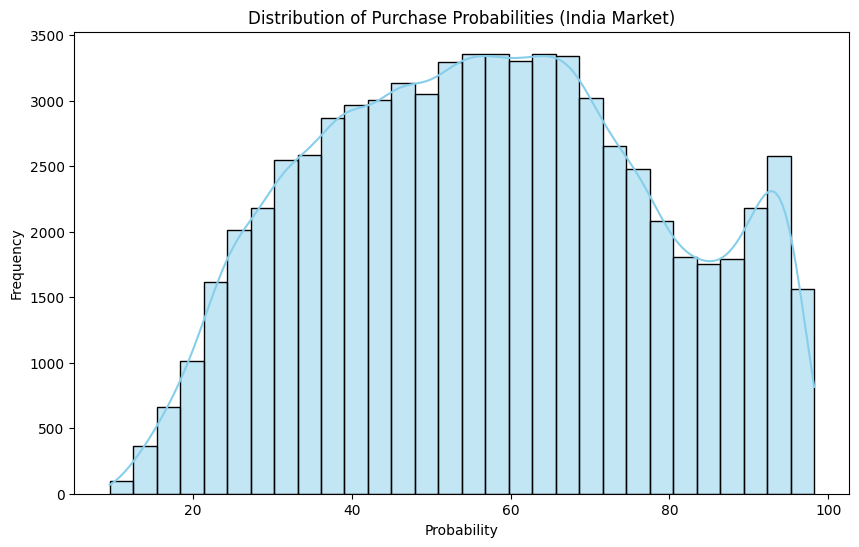

Chart saved successfully in ..\04_visuals


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create a folder for visuals if it doesn't exist
output_dir = "..\\04_visuals"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Example: Saving your Probability Distribution Chart
plt.figure(figsize=(10, 6))
sns.histplot(india_df['purchasing_probability_pct'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Purchase Probabilities (India Market)')
plt.xlabel('Probability')
plt.ylabel('Frequency')

plt.savefig(f"{output_dir}\\Python_Probability_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Chart saved successfully in {output_dir}")

### ***05: Final Data Formatting & Cleanup***

In [8]:
india_df['purchasing_probability_pct'] = india_df['purchasing_probability_pct'].round(2)  #--Rounding probabilities to 2 decimal places for better readability in output

india_df = india_df.drop(columns=['ann_income_aligned'])
india_df = india_df.drop(columns=['ann_income_standardized'])
india_df = india_df.rename(columns={'final_prediction': 'pur_prediction'})

display(india_df.head(10))

,id,curr_age,gender,ann_income,dt_maint,age_car,income_bracket,pur_prediction,purchasing_probability_pct
0,20710B05XL,54,0,1425390.0,2018-04-20,437,High,0,72.93
1,89602T51HX,47,0,1678954.0,2018-06-08,388,High,1,75.37
2,70190Z52IP,60,0,931624.0,2017-07-31,700,Low,1,82.11
3,25623V15MU,55,1,1106320.0,2017-07-31,700,Medium,1,82.27
4,36230I68CE,32,1,748465.0,2019-01-27,155,Low,0,29.88
5,11264G01HZ,48,1,1051927.0,2018-11-24,219,Medium,0,38.93
6,74250S23UO,26,1,1076402.0,2018-09-22,282,Medium,0,51.80
7,26735J66DB,45,1,1481949.0,2018-04-05,452,High,0,72.87
8,93404P60ED,55,0,1725607.0,2018-01-02,545,High,1,85.00
9,56557A36QV,64,1,312323.0,2018-04-23,434,Low,0,38.77


### ***06: Export Forecasted Dataset***

In [10]:
print("Actual Columns in India_DF:", india_df.columns.tolist()) #--Print all current columns so we can see the exact names (including case-sensitivity)

if 'prob_%' in india_df.columns:        #--Identify the Probability Column (Checking for both possibilities)
    prob_col = 'prob_%'
elif 'purchase_probability_pct' in india_df.columns:
    prob_col = 'purchase_probability_pct'
else:       #--If neither exists, we'll just look for any column containing 'prob'
        prob_col = [c for c in india_df.columns if 'prob' in c.lower()][0]

if 'pur_prediction' in india_df.columns:        #--Identify the Prediction Column
    pred_col = 'pur_prediction'
elif 'final_prediction' in india_df.columns:
    pred_col = 'final_prediction'
else:
    pred_col = [c for c in india_df.columns if 'predict' in c.lower()][0]

columns_to_export = ['id', 'curr_age', 'gender', 'ann_income', 'dt_maint', 'age_car', 'income_bracket', prob_col, pred_col]
#--Ensuring all columns to export exist in the DataFrame

india_final_export = india_df[columns_to_export]        #--Exporting the forecasted results to a CSV file
india_final_export.to_csv("..\\01_data\\03_forecast_results\\ABG_Motors_India_Forecast_Results.csv", index=False)

print(f"\n✅ SUCCESS! Exported using: {prob_col} and {pred_col}")

Actual Columns in India_DF: ['id', 'curr_age', 'gender', 'ann_income', 'dt_maint', 'age_car', 'income_bracket', 'pur_prediction', 'purchasing_probability_pct']

✅ SUCCESS! Exported using: purchasing_probability_pct and pur_prediction
